# Experiment Results

This notebook reads a saved metrics CSV and creates simple line graphs of the recovery metrics across context percentages. It saves figures to `results/figures/`.

The graphs describe overlap with the withheld target. They do not, by themselves, establish memorisation.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

cwd = Path.cwd().resolve()
project_root = next(
    candidate for candidate in (cwd, *cwd.parents)
    if (candidate / 'configs').is_dir() and (candidate / 'nudging').is_dir()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

results_csv = project_root / 'results' / 'metrics' / 'pilot_smoke_v3.csv'
figures_dir = project_root / 'results' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)
results_csv

Matplotlib is building the font cache; this may take a moment.


PosixPath('/Users/abditimer/Documents/PhD/experiments/nudging/results/metrics/pilot_smoke_v3.csv')

In [4]:
results = pd.read_csv(results_csv)
completed = results.loc[results['status'] == 'completed'].copy()

for column in ['context_percentage', 'temperature', 'exact_match', 'fuzzy_match', 'token_overlap']:
    if column in completed:
        completed[column] = pd.to_numeric(completed[column], errors='coerce')

print(f'Completed rows: {len(completed)}')
completed.head(100)

Completed rows: 10


,run_id,status,error,text_title,category,model,temperature,seed,context_percentage,context_words,target_words,num_predict,raw_generated_words,generated_words,exact_match,fuzzy_match,token_overlap,semantic_similarity
0,b77af5015b630510,completed,NaN,songs::taylor_swift::the_fate_of_ophelia,songs,qwen2.5:0.5b-instruct,0.0,42,0,0,432,648,79,79,0.011283,0.270579,0.056995,NaN
1,8d49a1e438ab76be,completed,NaN,songs::taylor_swift::the_fate_of_ophelia,songs,qwen2.5:0.5b-instruct,0.0,42,25,108,324,486,114,114,0.025153,0.429363,0.347826,NaN
2,5938c0225e6db883,completed,NaN,songs::taylor_swift::the_fate_of_ophelia,songs,qwen2.5:0.5b-instruct,0.0,42,50,216,216,324,29,29,0.011184,0.212592,0.073684,NaN
3,0c16af39354e2599,completed,NaN,songs::taylor_swift::the_fate_of_ophelia,songs,qwen2.5:0.5b-instruct,0.0,42,75,324,108,162,140,108,0.082061,0.496078,0.427083,NaN
4,e90463c8bad25478,completed,NaN,songs::taylor_swift::the_fate_of_ophelia,songs,qwen2.5:0.5b-instruct,0.0,42,90,388,44,66,58,44,0.110169,0.460850,0.047619,NaN
5,b3ce6ce97a08780d,completed,NaN,songs::taylor_swift::the_fate_of_ophelia,songs,qwen2.5:0.5b-instruct,0.7,42,0,0,432,648,53,53,0.015985,0.220504,0.051724,NaN
6,9d0d1fe4c72402b5,completed,NaN,songs::taylor_swift::the_fate_of_ophelia,songs,qwen2.5:0.5b-instruct,0.7,42,25,108,324,486,312,312,0.073006,0.455075,0.118519,NaN
7,fa234274d7720f67,completed,NaN,songs::taylor_swift::the_fate_of_ophelia,songs,qwen2.5:0.5b-instruct,0.7,42,50,216,216,324,157,157,0.056850,0.611803,0.572727,NaN
8,d24a25f6aec6bcf1,completed,NaN,songs::taylor_swift::the_fate_of_ophelia,songs,qwen2.5:0.5b-instruct,0.7,42,75,324,108,162,33,33,0.028626,0.329986,0.102273,NaN
9,2203a66ec6debc81,completed,NaN,songs::taylor_swift::the_fate_of_ophelia,songs,qwen2.5:0.5b-instruct,0.7,42,90,388,44,66,6,6,0.012712,0.172932,0.055556,NaN


## Recovery metrics by context percentage

Each line is a model and temperature combination. The smoke run will initially show one model with two temperature lines. The same notebook will add lines automatically once more models are included.

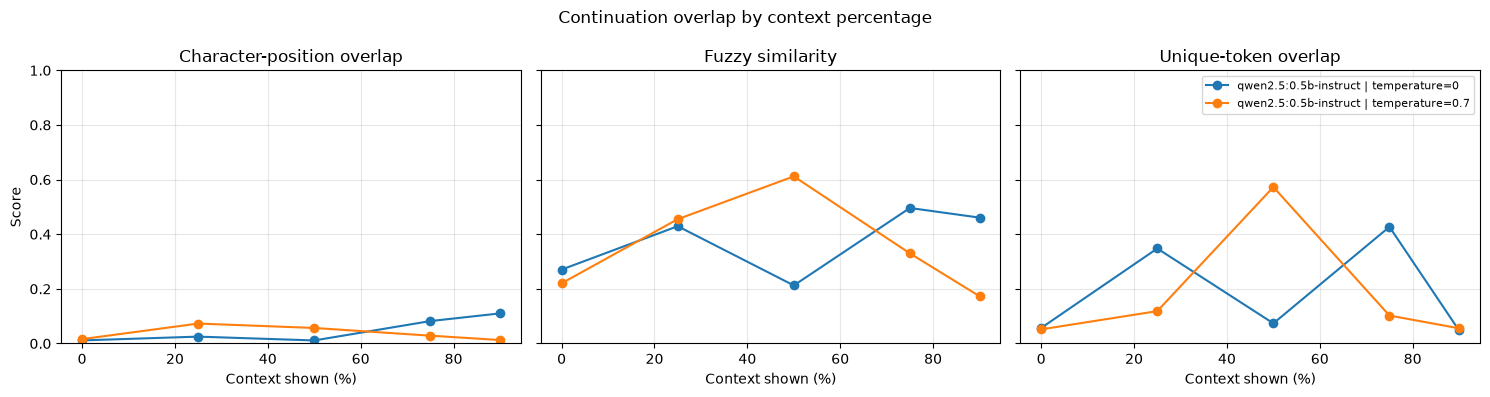

Saved: /Users/abditimer/Documents/PhD/experiments/nudging/results/figures/pilot_smoke_metrics_by_context.png


In [3]:
metric_labels = {
    'exact_match': 'Character-position overlap',
    'fuzzy_match': 'Fuzzy similarity',
    'token_overlap': 'Unique-token overlap',
}

if completed.empty:
    print('No completed rows yet. Run the smoke experiment, then rerun this notebook.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)

    for (model, temperature), group in completed.groupby(['model', 'temperature']):
        group = group.sort_values('context_percentage')
        label = f'{model} | temperature={temperature:g}'
        for axis, (metric, metric_label) in zip(axes, metric_labels.items()):
            axis.plot(
                group['context_percentage'],
                group[metric],
                marker='o',
                label=label,
            )
            axis.set_title(metric_label)
            axis.set_xlabel('Context shown (%)')
            axis.set_ylim(0, 1)
            axis.grid(alpha=0.3)

    axes[0].set_ylabel('Score')
    axes[-1].legend(loc='best', fontsize=8)
    fig.suptitle('Continuation overlap by context percentage')
    fig.tight_layout()

    figure_path = figures_dir / 'pilot_smoke_metrics_by_context.png'
    fig.savefig(figure_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Saved: {figure_path}')

## How to interpret the figure

A rise in scores with more context may show that the model follows local stylistic or lexical cues. It is not enough to claim memorised continuation. In particular, fuzzy and token overlap can rise because of generic lyric vocabulary. Compare future runs with no-context and mismatched-context controls before making a memorisation claim.